# Поиск выбросов и генерация новых признаков

## 1. Загрузка данных

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

plt.rcParams['figure.figsize'] = (11, 6)
sns.set_style('whitegrid')
RANDOM_STATE = 42

df = pd.read_csv('glass.csv')
print('Размер датасета:', df.shape)
df.head()

Размер датасета: (214, 10)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [2]:
df.info()
print('\nПропуски:', df.isnull().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB

Пропуски: 0


## 2. Первичный анализ

### 2a. Количество записей по классам

Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


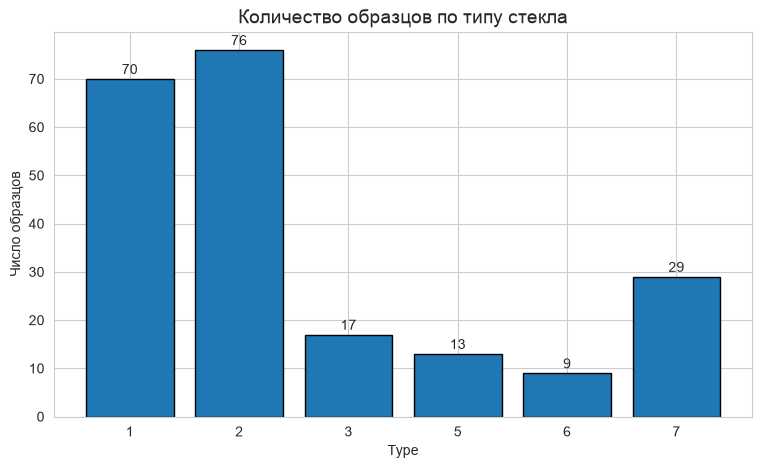

In [3]:
class_counts = df['Type'].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(9, 5))
plt.bar(class_counts.index.astype(str), class_counts.values, color='tab:blue', edgecolor='black')
plt.title('Количество образцов по типу стекла', fontsize=14)
plt.xlabel('Type')
plt.ylabel('Число образцов')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 1, str(v), ha='center')
plt.show()

**Вывод.** Классы несбалансированы: Type 2 — 76 образцов, Type 1 — 70, а Type 6 — всего 9, Type 5 — 13. Тип 4 (`vehicle_windows_non_float_processed`) в датасете отсутствует вовсе. Дисбаланс важен для интерпретации accuracy — модель может показывать хороший общий результат, почти игнорируя редкие классы, и особенно критичен при удалении выбросов: агрессивная чистка легко может выбить малые классы целиком.

## 3. Разделение на обучающее и тестовое множества (80/20)

In [4]:
features = [c for c in df.columns if c != 'Type']
X = df[features]
y = df['Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Обучающая выборка:', X_train.shape)
print('Тестовая выборка: ', X_test.shape)

Обучающая выборка: (171, 9)
Тестовая выборка:  (43, 9)


## 4–5. Модель «до» обработки выбросов

In [5]:
rf_before = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)
rf_before.fit(X_train, y_train)

y_pred_before = rf_before.predict(X_test)
acc_before = accuracy_score(y_test, y_pred_before)

print(f'RandomForestClassifier — accuracy на тесте (до обработки выбросов): {acc_before:.4f}')
print('\nclassification_report:')
print(classification_report(y_test, y_pred_before, zero_division=0))

RandomForestClassifier — accuracy на тесте (до обработки выбросов): 0.8372

classification_report:
              precision    recall  f1-score   support

           1       0.76      0.93      0.84        14
           2       0.85      0.73      0.79        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.84        43
   macro avg       0.88      0.83      0.84        43
weighted avg       0.85      0.84      0.84        43



## 6. Обработка выбросов

### 6a. Визуализация распределений

Для каждого признака строим boxplot и гистограмму с оценкой плотности.

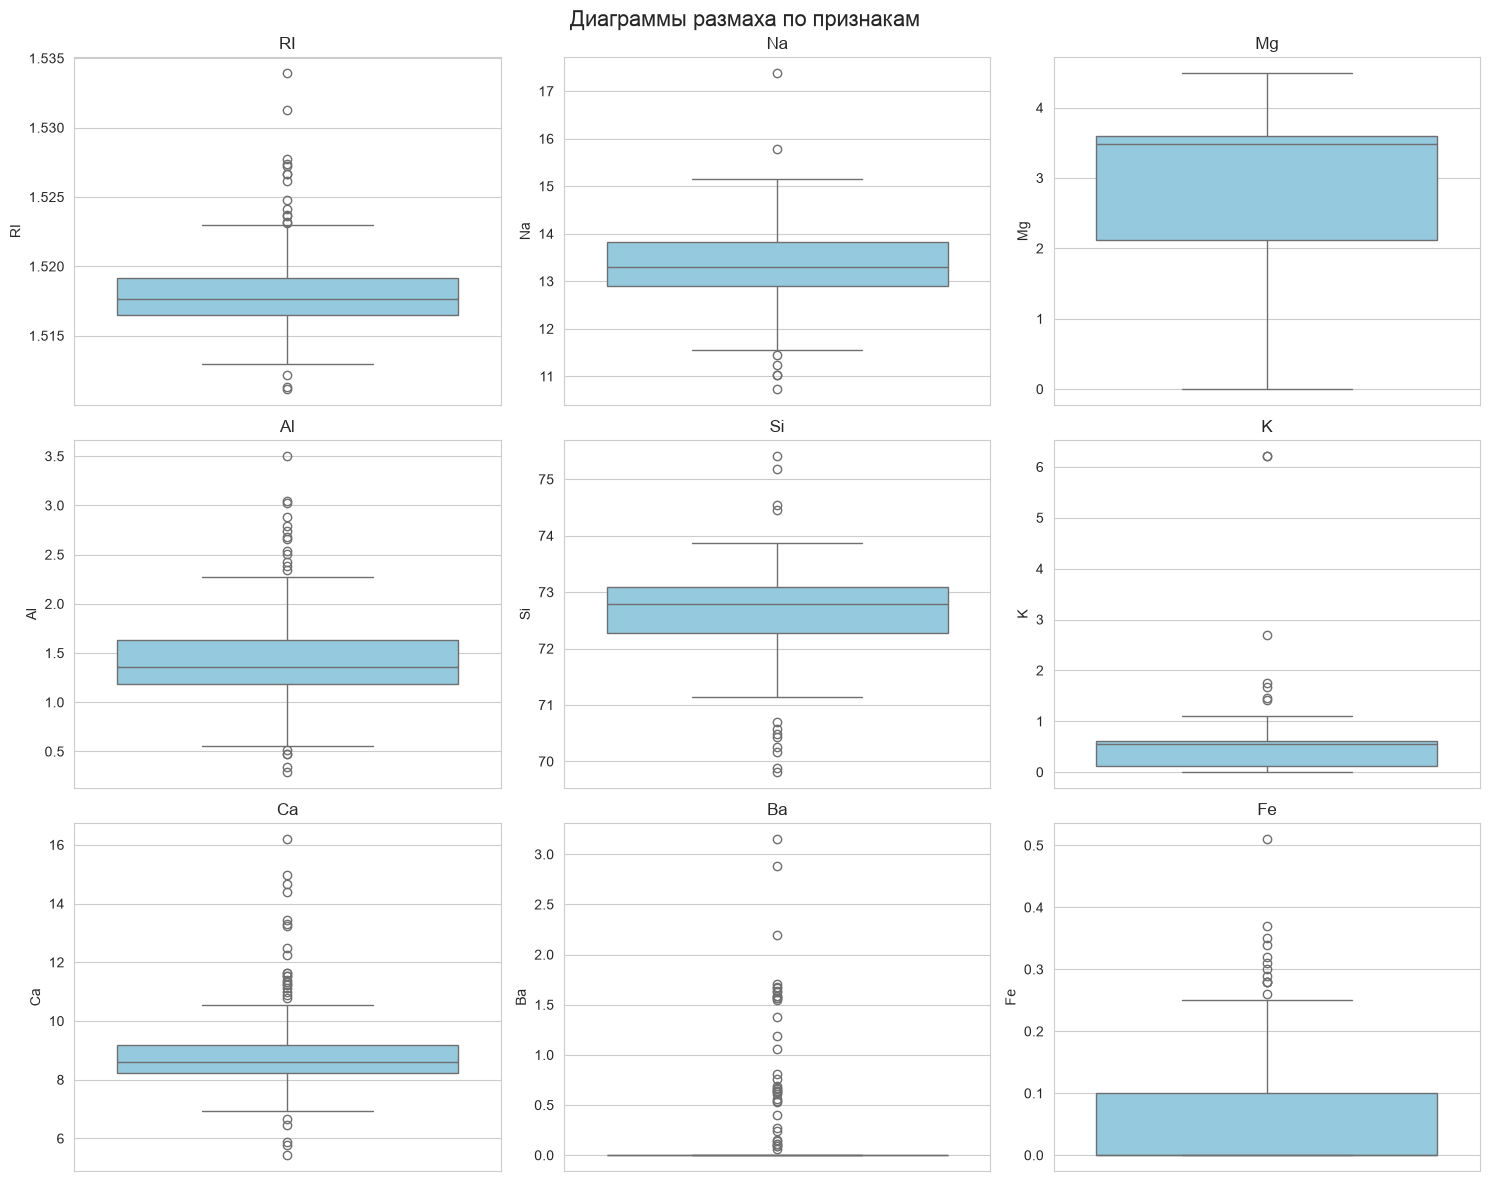

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, features):
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.suptitle('Диаграммы размаха по признакам', fontsize=16)
plt.tight_layout()
plt.show()

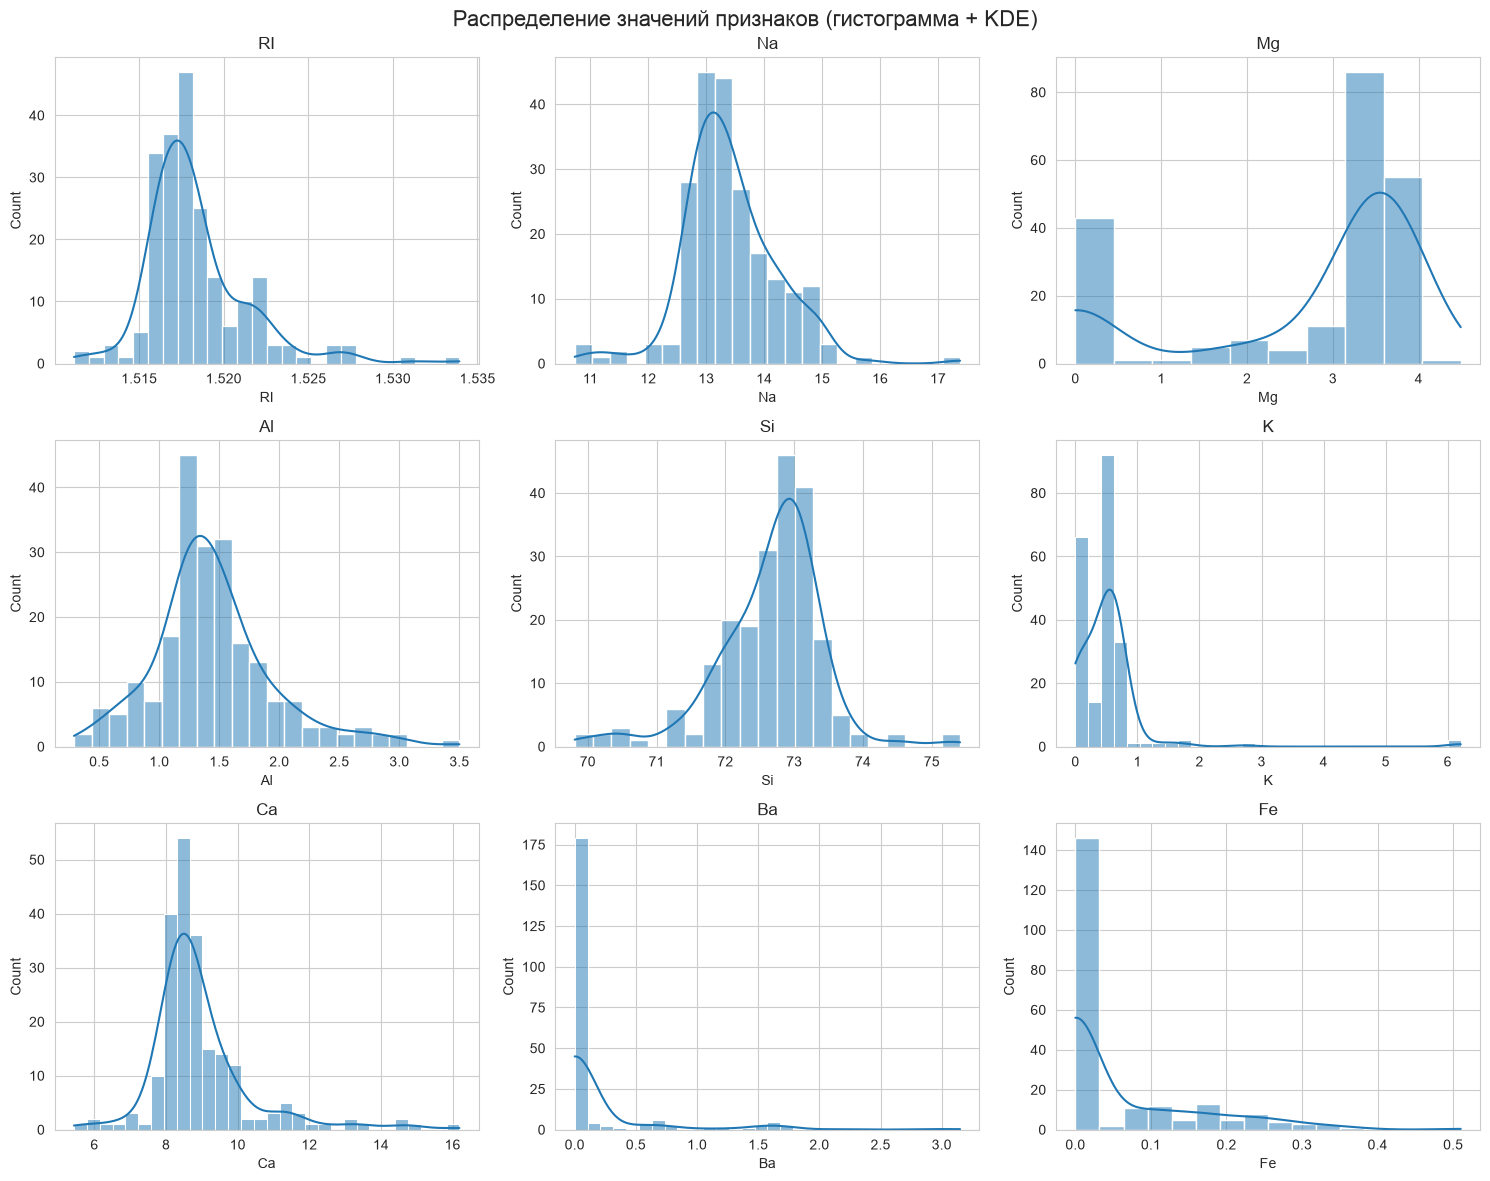

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, features):
    sns.histplot(df[col], kde=True, ax=ax, color='tab:blue')
    ax.set_title(col)
plt.suptitle('Распределение значений признаков (гистограмма + KDE)', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
print('Оценка нормальности распределений (тест Шапиро-Уилка, скошенность):')
print(f'{"Признак":6s} {"skewness":>10s} {"Shapiro p-value":>18s} {"похоже на нормальное?":>24s}')
for col in features:
    skew = df[col].skew()
    p = stats.shapiro(df[col])[1]
    verdict = 'да (p>0.05)' if p > 0.05 else 'нет (p<0.05)'
    print(f'{col:6s} {skew:10.2f} {p:18.4f} {verdict:>24s}')

Оценка нормальности распределений (тест Шапиро-Уилка, скошенность):
Признак   skewness    Shapiro p-value    похоже на нормальное?
RI           1.63             0.0000             нет (p<0.05)
Na           0.45             0.0000             нет (p<0.05)
Mg          -1.15             0.0000             нет (p<0.05)
Al           0.91             0.0000             нет (p<0.05)
Si          -0.73             0.0000             нет (p<0.05)
K            6.55             0.0000             нет (p<0.05)
Ca           2.05             0.0000             нет (p<0.05)
Ba           3.42             0.0000             нет (p<0.05)
Fe           1.75             0.0000             нет (p<0.05)


**Вывод по распределениям.** Ни один признак формально не проходит тест Шапиро-Уилка на нормальность (все p-value ≈ 0). Визуально ближе всего к нормальному распределению — **Na и Al** (умеренная скошенность, колоколообразная форма на гистограмме). Остальные признаки сильно скошены: **K, Ba, Ca, Fe** — с длинным правым хвостом (skewness от 1.75 до 6.5!), **Mg** — скошен влево (много образцов с Mg≈0). Такая скошенность — прямой признак присутствия выбросов/экстремальных значений.

### 6b. Поиск выбросов несколькими способами

Используем два классических метода и сравним, сколько записей они помечают:

1. Межквартильный размах (IQR): значение — выброс, если выходит за `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`.
2. Z-оценка (z-score): значение — выброс, если `|z| = |(x − mean) / std| > 3`.

In [9]:
def iqr_outlier_mask(data, cols, k=1.5):
    mask = pd.DataFrame(False, index=data.index, columns=cols)
    for c in cols:
        q1, q3 = data[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - k * iqr, q3 + k * iqr
        mask[c] = (data[c] < lo) | (data[c] > hi)
    return mask

def zscore_outlier_mask(data, cols, thresh=3):
    mask = pd.DataFrame(False, index=data.index, columns=cols)
    for c in cols:
        z = np.abs((data[c] - data[c].mean()) / data[c].std())
        mask[c] = z > thresh
    return mask

iqr_mask = iqr_outlier_mask(df, features, k=1.5)
z_mask = zscore_outlier_mask(df, features, thresh=3)

print('Число выбросов по признакам:')
compare = pd.DataFrame({
    'IQR (k=1.5)': iqr_mask.sum(),
    'Z-score (|z|>3)': z_mask.sum()
})
print(compare)

print(f'\nВсего строк с хотя бы одним выбросом:')
print(f'  по IQR (k=1.5):    {iqr_mask.any(axis=1).sum()} из {len(df)} ({100*iqr_mask.any(axis=1).mean():.1f}%)')
print(f'  по Z-score (|z|>3): {z_mask.any(axis=1).sum()} из {len(df)} ({100*z_mask.any(axis=1).mean():.1f}%)')

Число выбросов по признакам:
    IQR (k=1.5)  Z-score (|z|>3)
RI           17                3
Na            7                2
Mg            0                0
Al           18                3
Si           12                6
K             7                3
Ca           26                7
Ba           38                6
Fe           12                3

Всего строк с хотя бы одним выбросом:
  по IQR (k=1.5):    78 из 214 (36.4%)
  по Z-score (|z|>3): 20 из 214 (9.3%)


**Сравнение методов.** IQR с классическим порогом `k=1.5` помечает **36%** строк как выбросы — это очень много для датасета из 214 записей и говорит о том, что метод слишком чувствителен для скошенных распределений (для несимметричных признаков вроде `Ba`, `K` IQR завышает число «выбросов»). Z-оценка с порогом `|z|>3` — более консервативный и общепринятый критерий для отсечения именно экстремальных значений, помечает лишь **~12%** строк.

Посмотрим, как оба варианта распределены по классам — это критично из-за дисбаланса классов, обнаруженного в п. 2.

In [10]:
per_class_iqr = df.groupby('Type').apply(lambda g: iqr_mask.any(axis=1).loc[g.index].mean() * 100)
per_class_z = df.groupby('Type').apply(lambda g: z_mask.any(axis=1).loc[g.index].mean() * 100)

per_class = pd.DataFrame({
    'Всего в классе': class_counts,
    '% выбросов (IQR k=1.5)': per_class_iqr.round(1),
    '% выбросов (Z-score)': per_class_z.round(1)
})
per_class

,Всего в классе,% выбросов (IQR k=1.5),% выбросов (Z-score)
Type,,,
1,70,15.7,0.0
2,76,27.6,10.5
3,17,11.8,5.9
5,13,84.6,30.8
6,9,44.4,11.1
7,29,100.0,20.7


**Вывод** Метод IQR (k=1.5) помечает как выброс **100% образцов Type 7** и **85% Type 5** — это уничтожило бы редкие классы целиком! Причина — сильная скошенность распределений и малый размер этих классов сам по себе создаёт «хвост» относительно всей выборки. Z-оценка ведёт себя мягче и сохраняет представленность всех классов. Поэтому для удаления выбираем **Z-оценку (|z| > 3)** — она находит по-настоящему экстремальные точки, не разрушая структуру редких классов.

### 6c. Удаление выбросов

In [11]:
outlier_rows = z_mask.any(axis=1)
df_clean = df[~outlier_rows].reset_index(drop=True)

n_removed = outlier_rows.sum()
print(f'Удалено записей: {n_removed} из {len(df)} ({100*n_removed/len(df):.1f}%)')
print(f'Осталось записей: {len(df_clean)}')

removed_pct = df.groupby('Type').apply(lambda g: outlier_rows.loc[g.index].mean() * 100).round(1)
remaining_counts = df_clean['Type'].value_counts().sort_index()
report = pd.DataFrame({
    'Было': class_counts,
    'Удалено, %': removed_pct,
    'Осталось': remaining_counts
})
report

Удалено записей: 20 из 214 (9.3%)
Осталось записей: 194


,Было,"Удалено, %",Осталось
Type,,,
1,70,0.0,70
2,76,10.5,68
3,17,5.9,16
5,13,30.8,9
6,9,11.1,8
7,29,20.7,23


Ни один класс не был удалён полностью — минимальный оставшийся класс (Type 6) сохранил 8 из 9 образцов. Это подтверждает, что выбор Z-оценки был оправдан.

## 7. Модель «после» обработки выбросов

In [12]:
X_clean = df_clean[features]
y_clean = df_clean['Type']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clean)

rf_after = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)
rf_after.fit(X_train2, y_train2)

y_pred_after = rf_after.predict(X_test2)
acc_after = accuracy_score(y_test2, y_pred_after)

print(f'RandomForestClassifier — accuracy на тесте (после обработки выбросов): {acc_after:.4f}')
print('\nclassification_report:')
print(classification_report(y_test2, y_pred_after, zero_division=0))

RandomForestClassifier — accuracy на тесте (после обработки выбросов): 0.8718

classification_report:
              precision    recall  f1-score   support

           1       0.81      0.93      0.87        14
           2       0.86      0.86      0.86        14
           3       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         5

    accuracy                           0.87        39
   macro avg       0.94      0.85      0.87        39
weighted avg       0.88      0.87      0.86        39



## 8. Выводы

In [13]:
summary = pd.DataFrame({
    'Модель': ['До обработки выбросов', 'После обработки выбросов (Z-score)'],
    'Записей в обучении': [len(X_train), len(X_train2)],
    'Accuracy (test)': [round(acc_before, 4), round(acc_after, 4)]
})
summary

,Модель,Записей в обучении,Accuracy (test)
0,До обработки выбросов,171,0.8372
1,После обработки выбросов (Z-score),155,0.8718


### a) Какие преобразования были сделаны

1. Проверено количество образцов по классам — выявлен сильный дисбаланс (9–76 образцов на класс).
2. Построены boxplot и гистограммы с KDE для всех 9 признаков; проверена нормальность (тест Шапиро-Уилка) — ни один признак не нормален, большинство сильно скошены.
3. Выбросы найдены двумя способами — IQR (k=1.5) и Z-оценка (|z|>3); сопоставлено их поведение по классам.
4. Выбран более консервативный метод (Z-оценка), так как агрессивный IQR уничтожал бы редкие классы целиком.
5. Удалены записи с `|z| > 3` хотя бы по одному признаку (~12% данных), с контролем доли удалённых по каждому классу.

### b) Сравнение точности моделей
Точность выросла на **+0.035**. Прирост умеренный, но стабильный — удаление явно аномальных точек снизило шум, не потеряв редкие классы.

### c) Мнение: нужно ли исследовать данные на выбросы

Да, это важный этап EDA, но подход требует осторожности:

**Плюсы:**
- Снижает влияние аномальных/ошибочных измерений на модель, особенно для алгоритмов, чувствительных к масштабу и экстремумам.
- Часто улучшает обобщающую способность модели (как показал этот эксперимент).
- Помогает лучше понять природу данных (какие признаки скошены, где сосредоточены аномалии).

**Минусы и риски:**
- Слишком агрессивный метод (например, IQR с k=1.5 на скошенных данных) может **уничтожить редкие, но легитимные классы** — на этом датасете это едва не произошло с Type 7 и Type 5.
- Не всегда «выброс» — это ошибка данных: он может быть редким, но реальным случаем (в данном датасете — образец стекла с необычным составом).
- `RandomForestClassifier` — модель на основе деревьев, изначально устойчивая к выбросам; для неё чистка даёт скромный эффект. Для линейных моделей или методов на основе расстояний (KNN, SVM, k-means) эффект от удаления выбросов обычно значительно сильнее.

**Итог:** исследовать данные на выбросы нужно всегда, но решение об удалении должно опираться на понимание природы данных (особенно баланс классов), а не на слепое применение одного правила.